## Nama: M Muzammil Aditya Putra
## Nim: 4222301055
## Kelas: 6B-Pagi

# CNN Image Classification: Deteksi Jenis Sampah di Kampus
**Dataset:** Trash Type Image Dataset — [Kaggle](https://www.kaggle.com/datasets/farzadnekouei/trash-type-image-dataset)  
**Kelas:** Cardboard · Glass · Metal · Paper · Plastic · Trash  
**Framework:** TensorFlow / Keras

---

##  Download Dataset dari Kaggle


In [ ]:
import os
DATA_DIR = 'archive/TrashType_Image_Dataset'
print('Kelas yang tersedia:', os.listdir(DATA_DIR))

Kelas yang tersedia: ['cardboard', 'metal', 'trash', 'plastic', 'glass', 'paper']


## Import Library

In [9]:
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
from sklearn.metrics import classification_report, confusion_matrix

print('TensorFlow version:', tf.__version__)

TensorFlow version: 2.21.0


## Preprocessing & Data Augmentation

In [10]:
train_datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=20,
    zoom_range=0.2,
    horizontal_flip=True,
    validation_split=0.2      # 80% train, 20% validasi
)

train_data = train_datagen.flow_from_directory(
    DATA_DIR,
    target_size=(128, 128),
    batch_size=32,
    class_mode='categorical',
    subset='training',
    shuffle=True,
    seed=42
)

val_data = train_datagen.flow_from_directory(
    DATA_DIR,
    target_size=(128, 128),
    batch_size=32,
    class_mode='categorical',
    subset='validation',
    shuffle=False,
    seed=42
)

print(f'Kelas yang terdeteksi : {train_data.class_indices}')
print(f'Jumlah data training  : {train_data.samples}')
print(f'Jumlah data validasi  : {val_data.samples}')

Found 2024 images belonging to 6 classes.
Found 503 images belonging to 6 classes.
Kelas yang terdeteksi : {'cardboard': 0, 'glass': 1, 'metal': 2, 'paper': 3, 'plastic': 4, 'trash': 5}
Jumlah data training  : 2024
Jumlah data validasi  : 503


### Visualisasi Sample Dataset

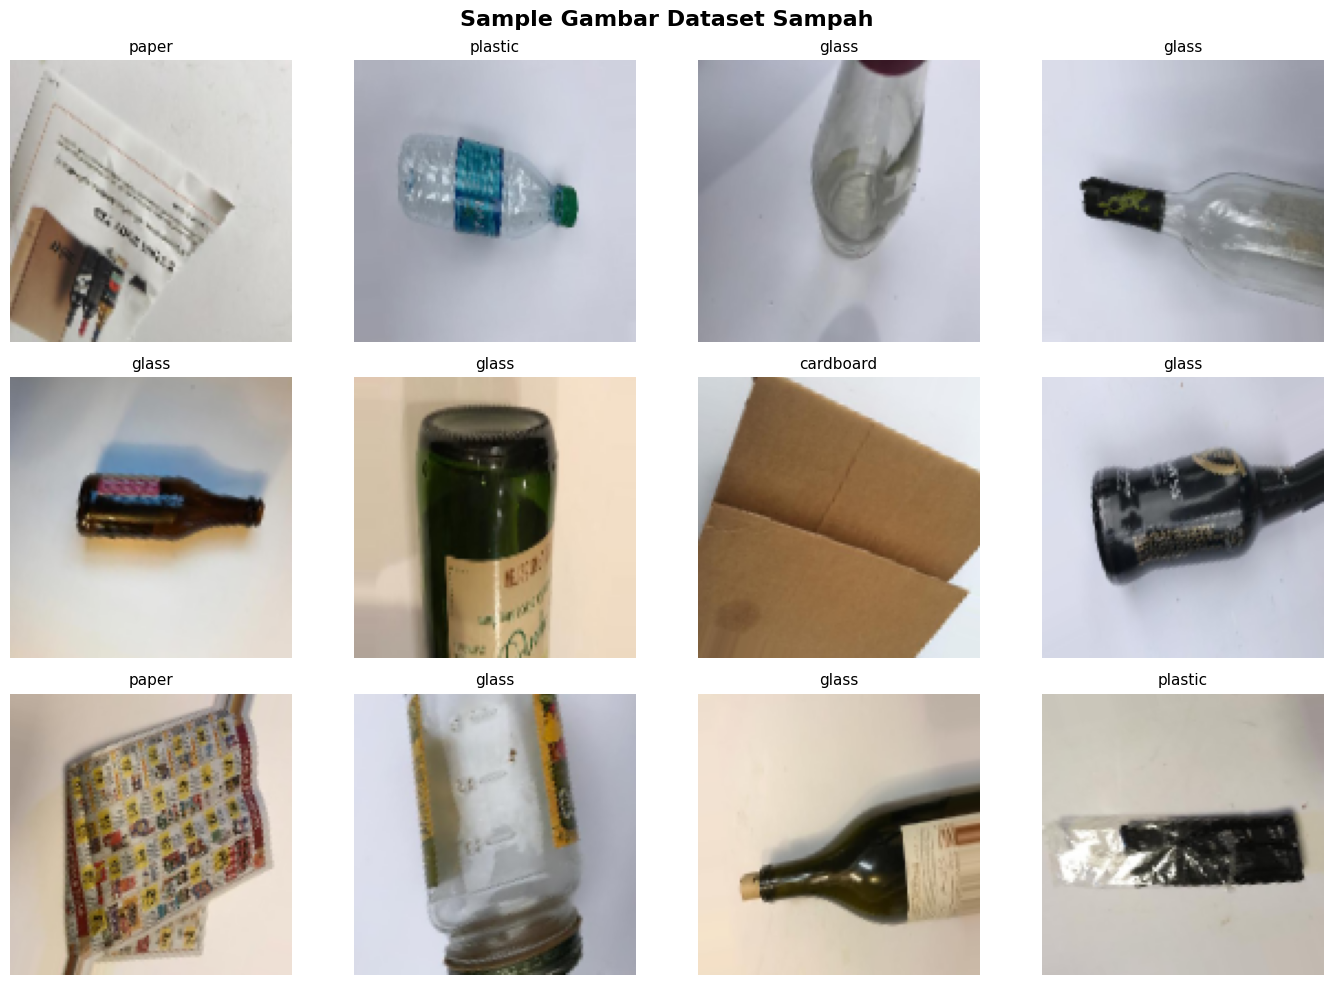

In [11]:
x_batch, y_batch = next(train_data)
class_names = list(train_data.class_indices.keys())

fig, axes = plt.subplots(3, 4, figsize=(14, 10))
fig.suptitle('Sample Gambar Dataset Sampah', fontsize=16, fontweight='bold')
for i, ax in enumerate(axes.flatten()):
    ax.imshow(x_batch[i])
    ax.set_title(class_names[np.argmax(y_batch[i])], fontsize=11)
    ax.axis('off')
plt.tight_layout()
plt.show()

## Building CNN Model

In [12]:
model = Sequential([
    # Blok Konvolusi 1
    Conv2D(32, (3,3), activation='relu', input_shape=(128, 128, 3)),
    MaxPooling2D(2, 2),
    Dropout(0.25),

    # Blok Konvolusi 2
    Conv2D(64, (3,3), activation='relu'),
    MaxPooling2D(2, 2),
    Dropout(0.25),

    # Fully Connected Layer
    Flatten(),
    Dense(128, activation='relu'),
    Dropout(0.5),
    Dense(train_data.num_classes, activation='softmax')
])

model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_2 (Conv2D)               │ (None, 126, 126, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 63, 63, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 63, 63, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 61, 61, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 30, 30, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 30, 30, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 57600)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 128)            │     7,372,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_5 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 6)              │           774 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 7,393,094 (28.20 MB)

 Trainable params: 7,393,094 (28.20 MB)

 Non-trainable params: 0 (0.00 B)

## Compile & Training

In [13]:
model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

early_stop = EarlyStopping(
    monitor='val_accuracy',
    patience=3,
    restore_best_weights=True,
    verbose=1
)

history = model.fit(
    train_data,
    epochs=10,
    validation_data=val_data,
    callbacks=[early_stop]
)

model.save('trash_classifier.h5')
print('\nModel tersimpan: trash_classifier.h5')

Epoch 1/10
64/64 ━━━━━━━━━━━━━━━━━━━━ 109s 2s/step - accuracy: 0.2648 - loss: 2.0027 - val_accuracy: 0.3797 - val_loss: 1.5870
Epoch 2/10
64/64 ━━━━━━━━━━━━━━━━━━━━ 45s 708ms/step - accuracy: 0.3542 - loss: 1.5135 - val_accuracy: 0.3996 - val_loss: 1.4346
Epoch 3/10
64/64 ━━━━━━━━━━━━━━━━━━━━ 48s 746ms/step - accuracy: 0.3972 - loss: 1.4473 - val_accuracy: 0.3956 - val_loss: 1.4046
Epoch 4/10
64/64 ━━━━━━━━━━━━━━━━━━━━ 53s 823ms/step - accuracy: 0.4644 - loss: 1.3619 - val_accuracy: 0.4513 - val_loss: 1.3478
Epoch 5/10
64/64 ━━━━━━━━━━━━━━━━━━━━ 53s 820ms/step - accuracy: 0.4620 - loss: 1.3371 - val_accuracy: 0.4672 - val_loss: 1.3295
Epoch 6/10
64/64 ━━━━━━━━━━━━━━━━━━━━ 53s 820ms/step - accuracy: 0.4827 - loss: 1.2970 - val_accuracy: 0.5189 - val_loss: 1.2751
Epoch 7/10
64/64 ━━━━━━━━━━━━━━━━━━━━ 53s 824ms/step - accuracy: 0.5049 - loss: 1.2700 - val_accuracy: 0.5408 - val_loss: 1.1969
Epoch 8/10
64/64 ━━━━━━━━━━━━━━━━━━━━ 53s 826ms/step - accuracy: 0.5069 - loss: 1.2569 - val_accura


Model tersimpan: trash_classifier.h5


## Visualisasi Kurva Training

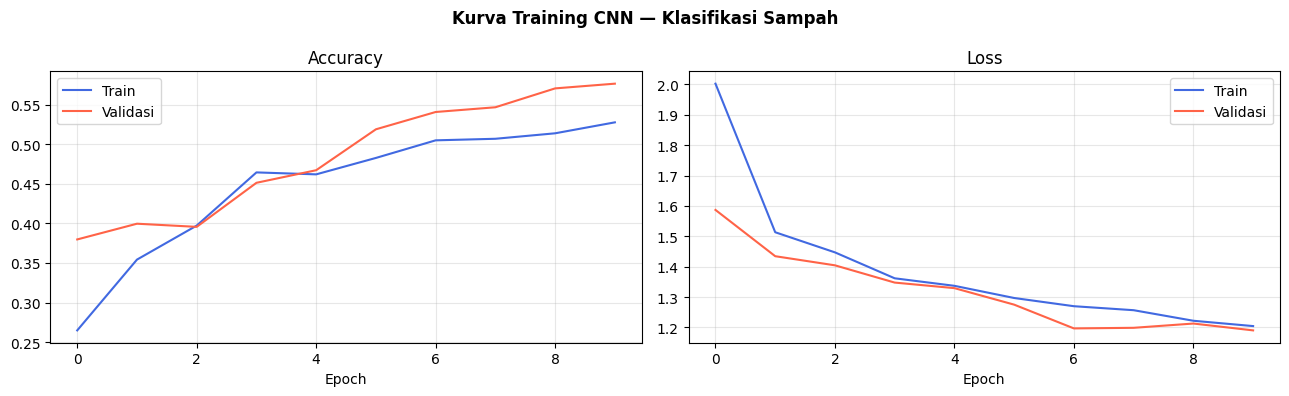

In [14]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 4))
fig.suptitle('Kurva Training CNN — Klasifikasi Sampah', fontweight='bold')

ax1.plot(history.history['accuracy'],     label='Train',    color='royalblue')
ax1.plot(history.history['val_accuracy'], label='Validasi', color='tomato')
ax1.set_title('Accuracy'); ax1.set_xlabel('Epoch')
ax1.legend(); ax1.grid(True, alpha=0.3)

ax2.plot(history.history['loss'],     label='Train',    color='royalblue')
ax2.plot(history.history['val_loss'], label='Validasi', color='tomato')
ax2.set_title('Loss'); ax2.set_xlabel('Epoch')
ax2.legend(); ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## Evaluasi Model

In [15]:
val_loss, val_acc = model.evaluate(val_data, verbose=0)
print(f'Validation Accuracy : {val_acc*100:.2f}%')
print(f'Validation Loss     : {val_loss:.4f}')

Validation Accuracy : 58.65%
Validation Loss     : 1.1893


In [16]:
val_data.reset()
y_pred = np.argmax(model.predict(val_data, verbose=0), axis=1)
y_true = val_data.classes

print('=== Classification Report ===')
print(classification_report(y_true, y_pred, target_names=class_names))

=== Classification Report ===
              precision    recall  f1-score   support

   cardboard       0.80      0.88      0.83        80
       glass       0.69      0.33      0.45       100
       metal       0.49      0.55      0.52        82
       paper       0.53      0.75      0.62       118
     plastic       0.55      0.62      0.58        96
       trash       0.00      0.00      0.00        27

    accuracy                           0.59       503
   macro avg       0.51      0.52      0.50       503
weighted avg       0.57      0.59      0.56       503



### Confusion Matrix

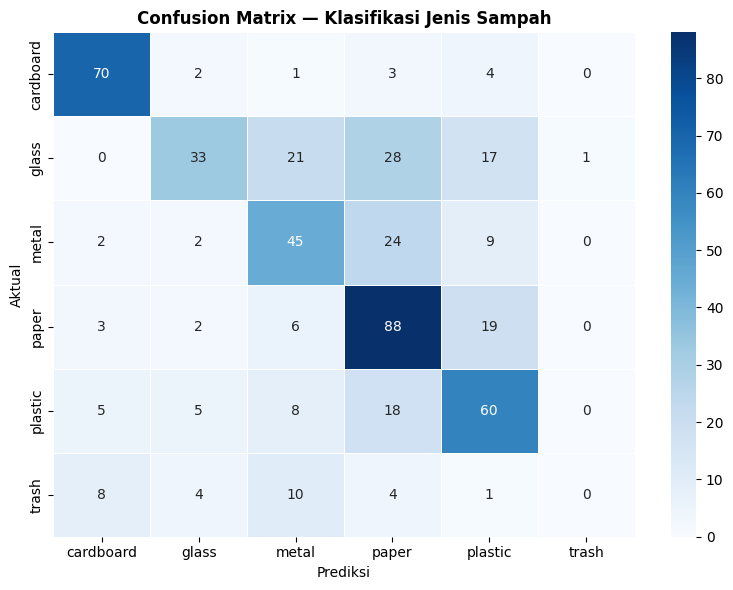

In [17]:
cm = confusion_matrix(y_true, y_pred)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=class_names, yticklabels=class_names,
            linewidths=0.5)
plt.title('Confusion Matrix — Klasifikasi Jenis Sampah', fontweight='bold')
plt.xlabel('Prediksi'); plt.ylabel('Aktual')
plt.tight_layout()
plt.show()

## Prediksi Gambar Baru

In [ ]:
from tensorflow.keras.preprocessing import image

def predict_image(image_path):
    img = image.load_img(image_path, target_size=(128, 128))
    img_array = image.img_to_array(img) / 255.0
    img_array = np.expand_dims(img_array, axis=0)

    predictions = model.predict(img_array, verbose=0)[0]
    predicted_class = class_names[np.argmax(predictions)]
    confidence = np.max(predictions) * 100

    plt.figure(figsize=(4, 4))
    plt.imshow(image.load_img(image_path, target_size=(128, 128)))
    plt.title(f'Prediksi: {predicted_class.upper()}\nConfidence: {confidence:.1f}%',
              fontweight='bold')
    plt.axis('off')
    plt.show()

    print('\nSkor per kelas:')
    for cls, prob in zip(class_names, predictions):
        bar = '█' * int(prob * 30)
        print(f'  {cls:<12}: {bar:<30} {prob*100:5.1f}%')

# Contoh penggunaan:
# predict_image('foto_sampah.jpg')